<a href="https://colab.research.google.com/github/dylan199512/Predicting-High-Cost-Hospitals-Using-AI-and-MSPB-Data-2/blob/main/Predicting_High%E2%80%91Cost_Hospitals_Using_AI_and_MSPB_Data_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Medicare_Hospital_Spending_Per_Patient-Hospital.csv to Medicare_Hospital_Spending_Per_Patient-Hospital.csv


Saving Hospital_General_Information (1).csv to Hospital_General_Information (1).csv


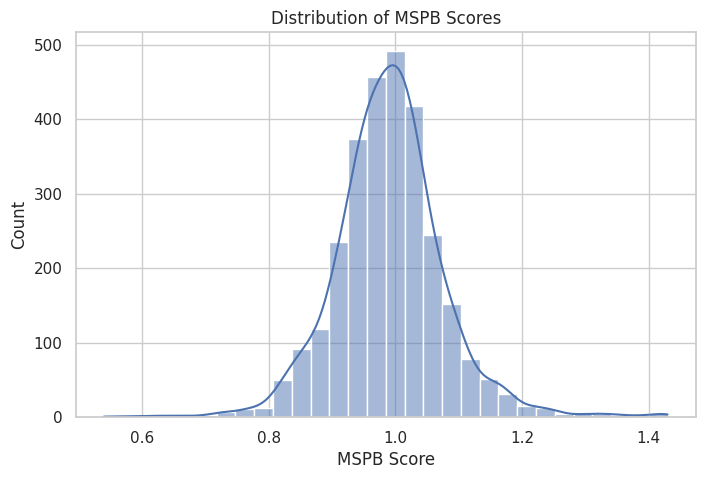

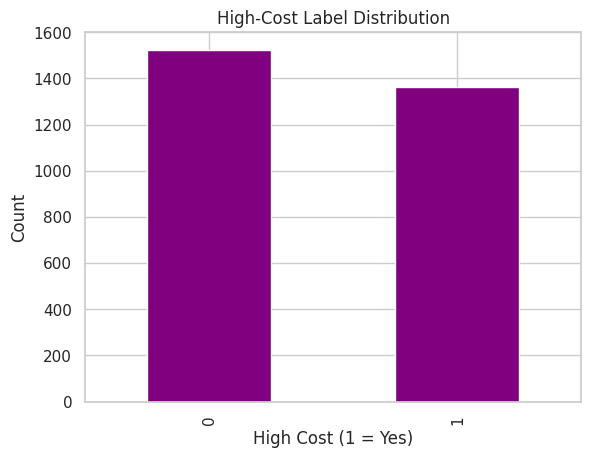

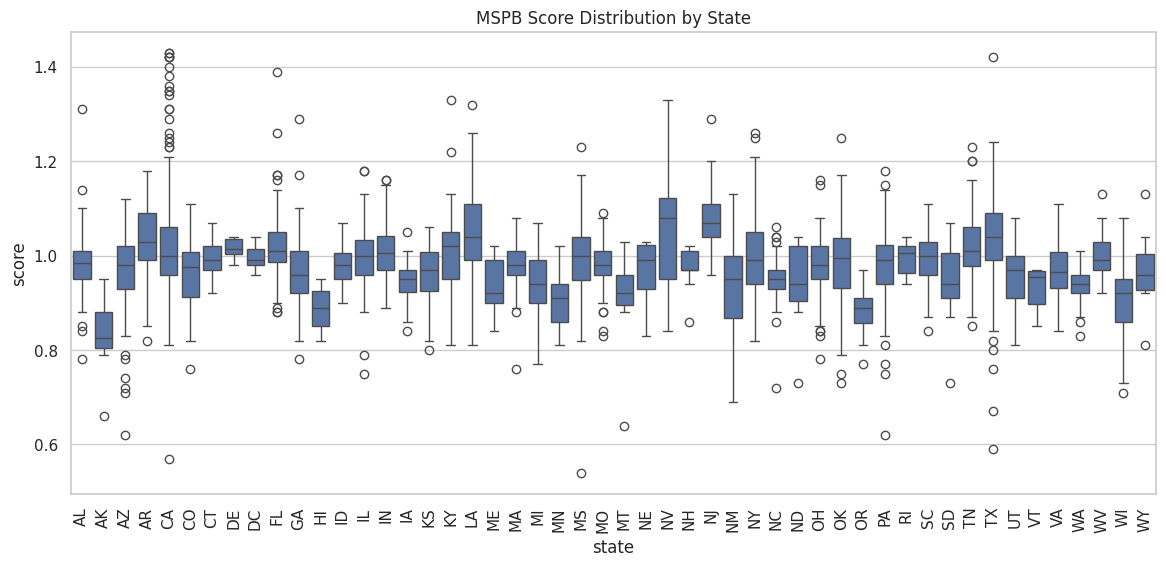

/tmp/ipykernel_4623/1657427049.py:168: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_mspb.index, y=state_mspb.values, palette='viridis')


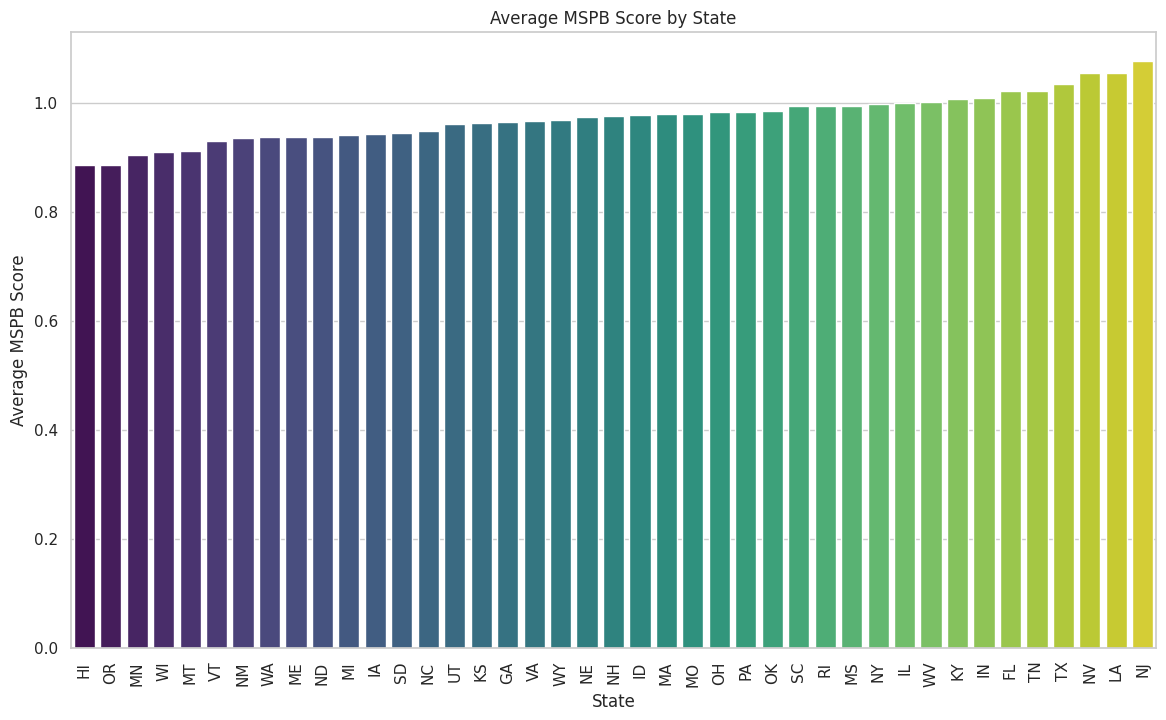

/tmp/ipykernel_4623/1657427049.py:179: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=high_cost_rate.index, y=high_cost_rate.values, palette='rocket')


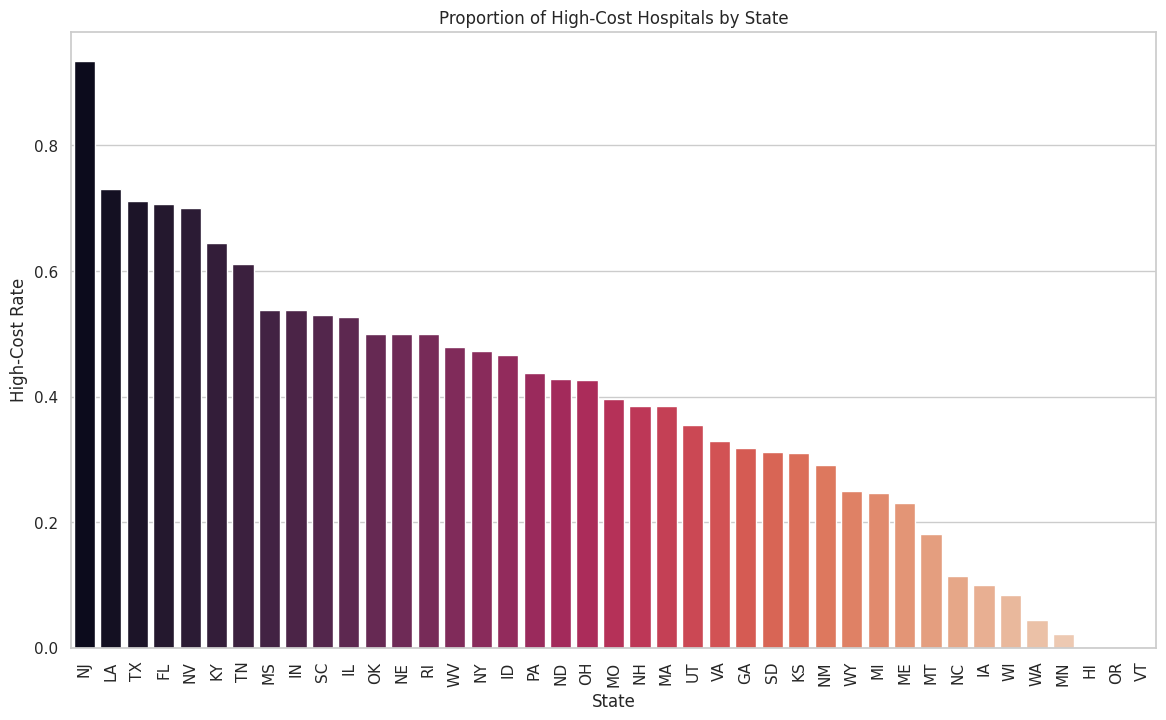

/tmp/ipykernel_4623/1657427049.py:206: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='region', y='score', palette='Set2')


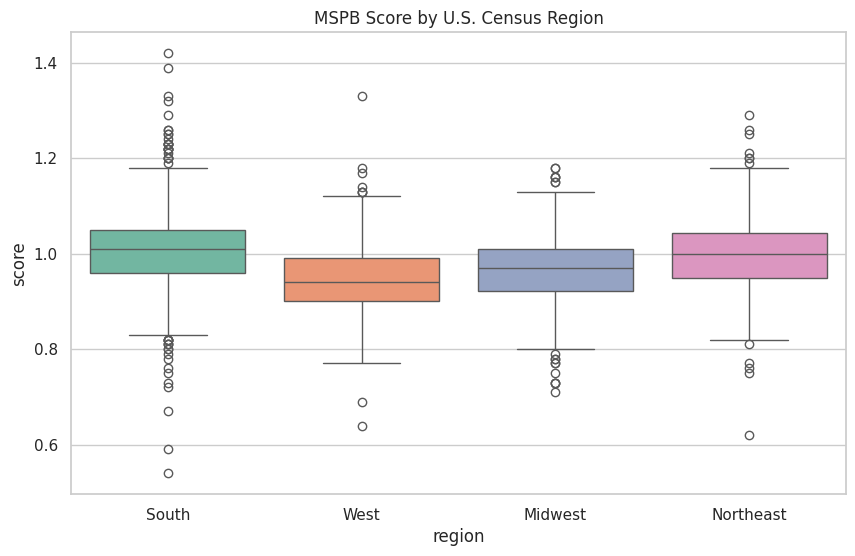

/tmp/ipykernel_4623/1657427049.py:214: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=county_mspb.head(20).index, x=county_mspb.head(20).values, palette='magma')


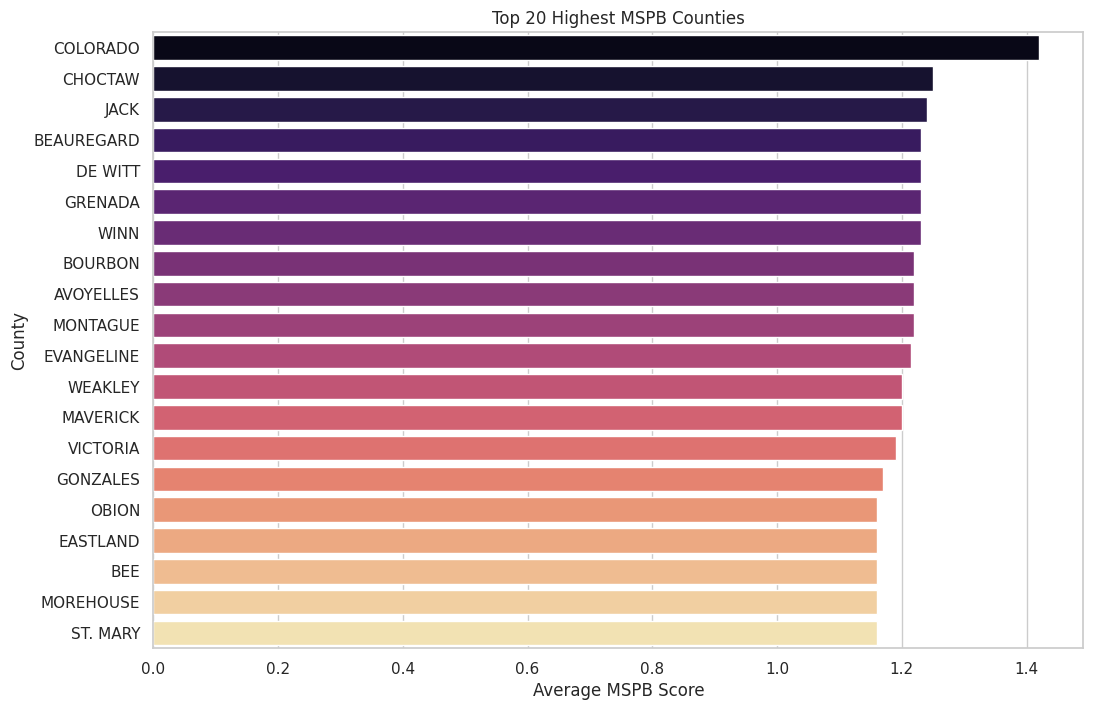

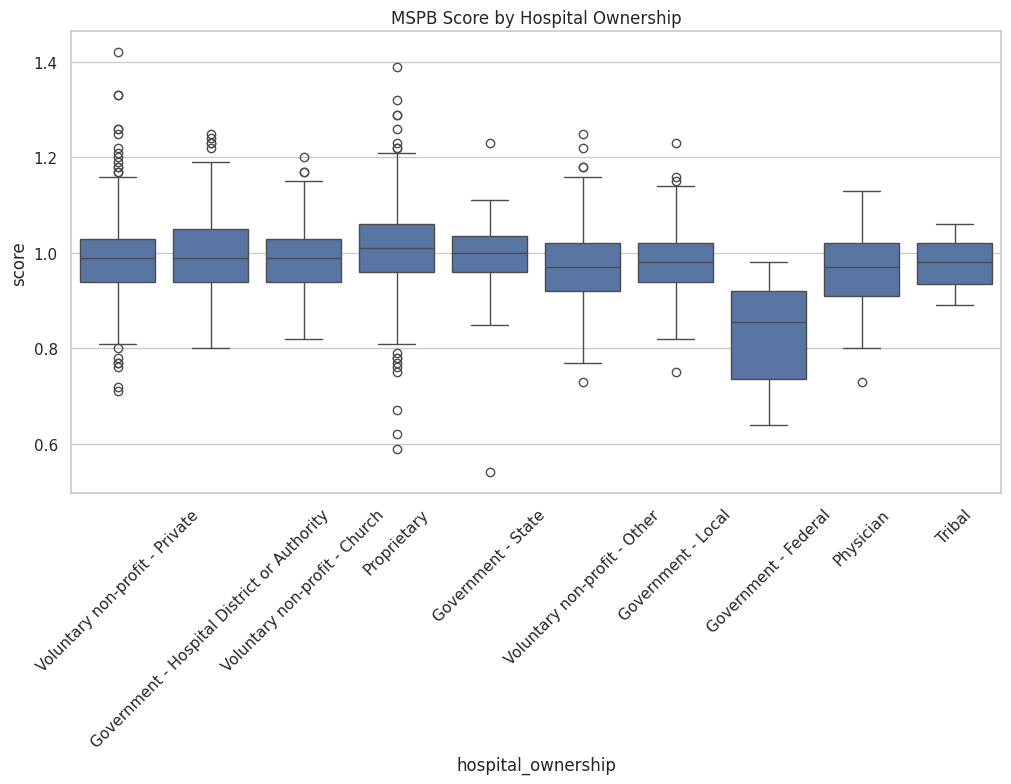

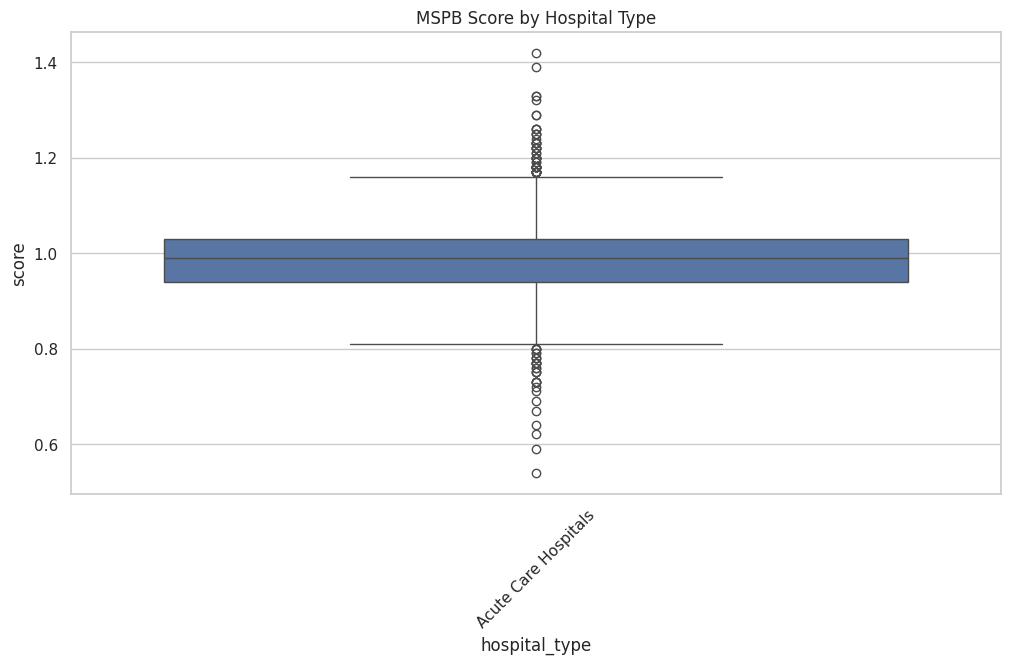

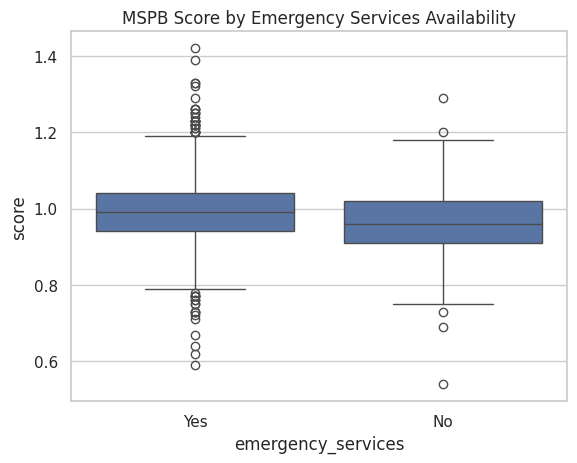

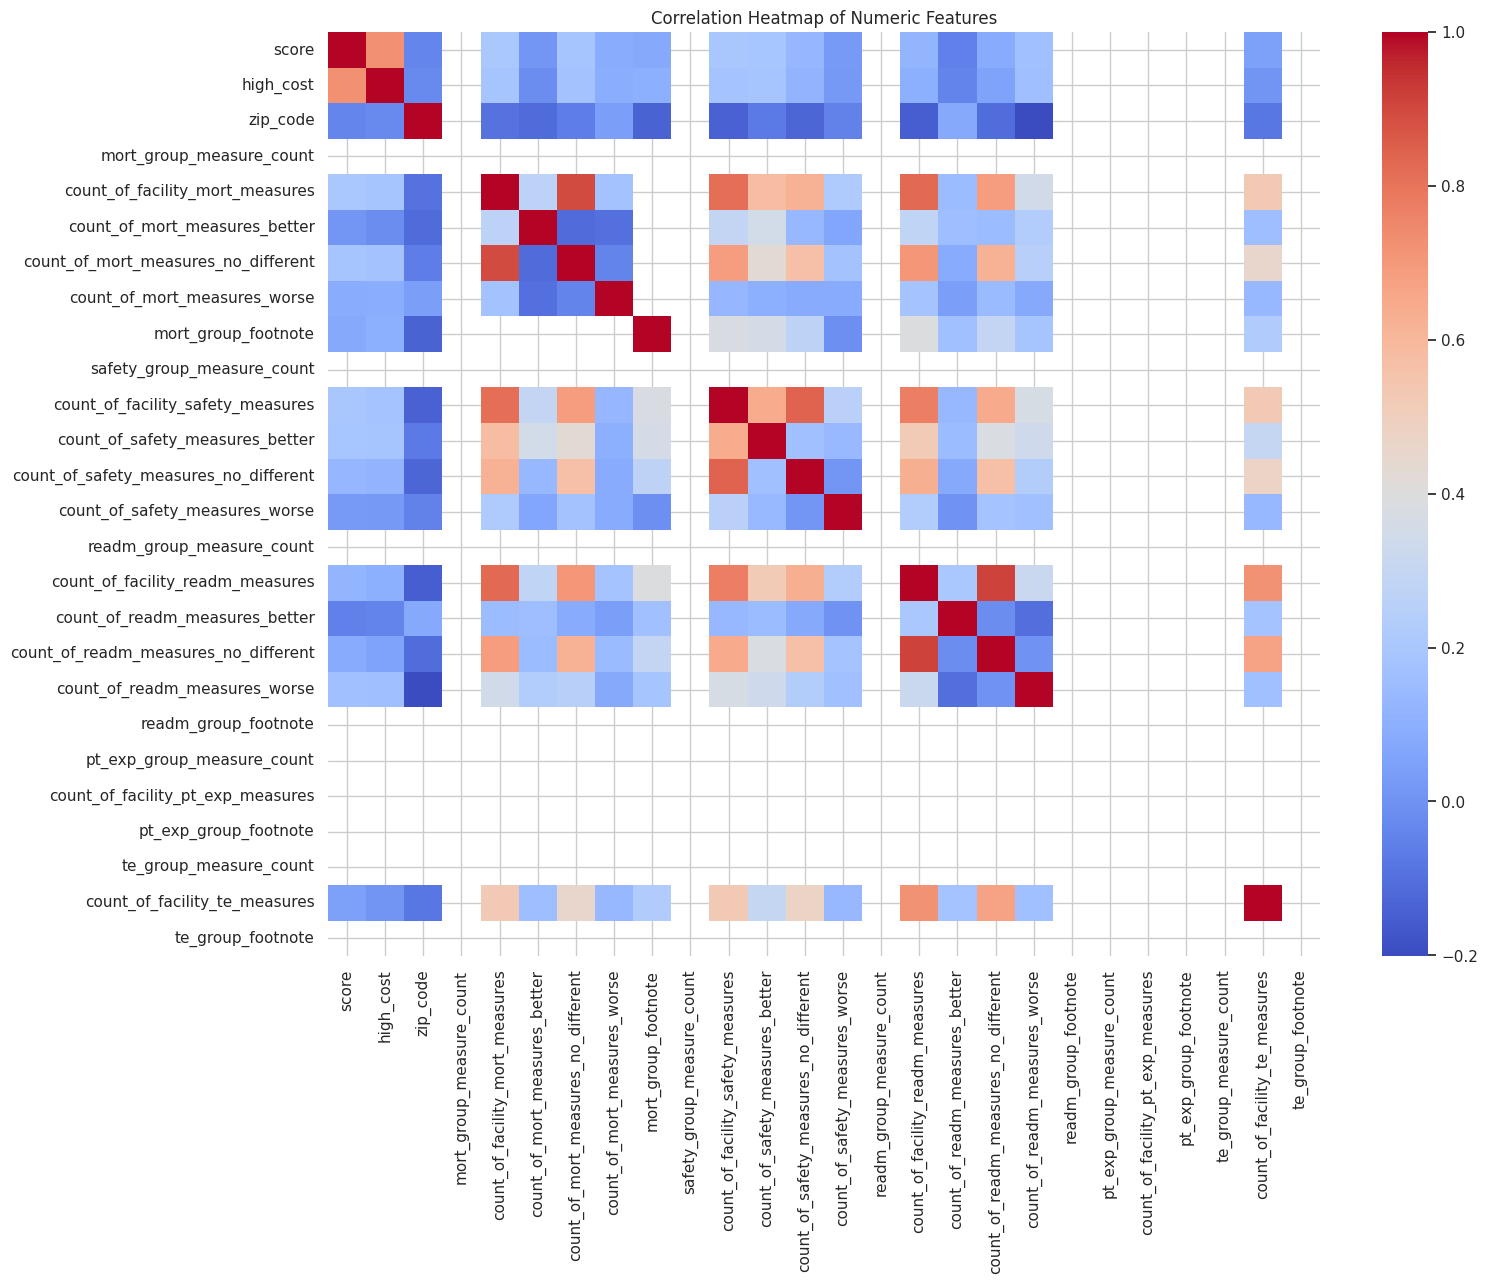

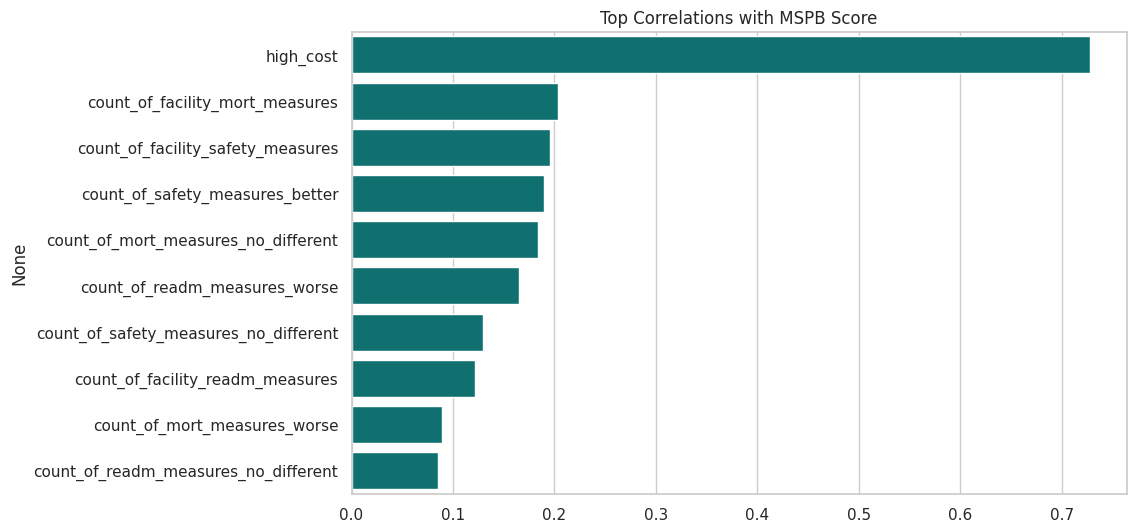

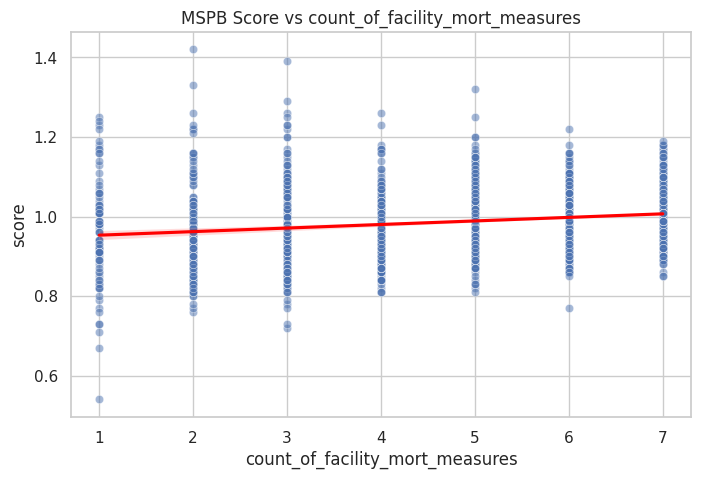

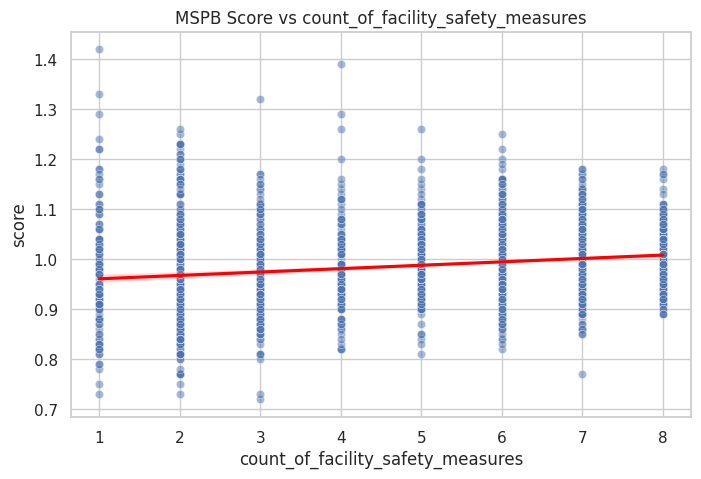

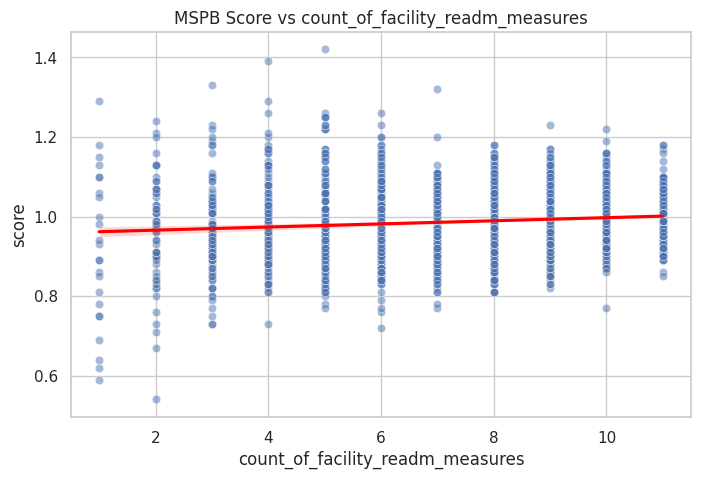

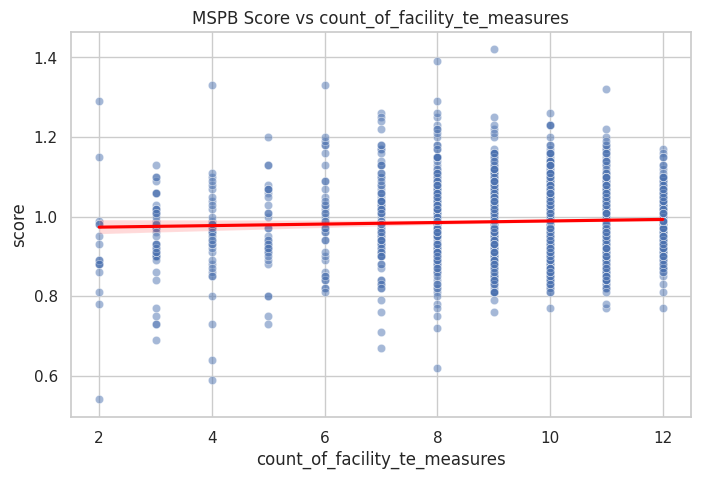

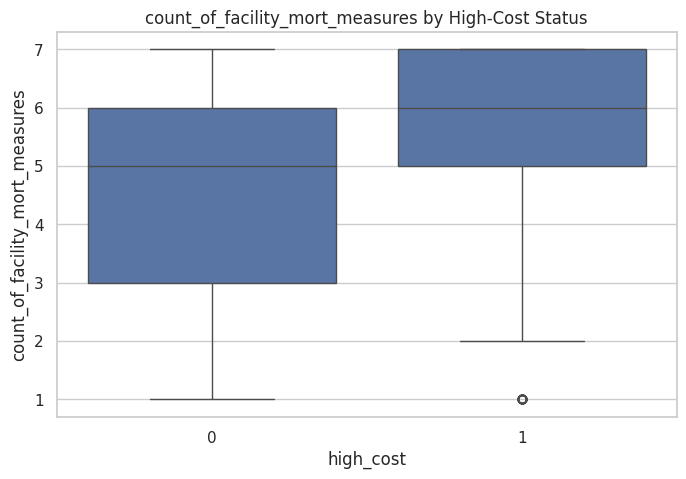

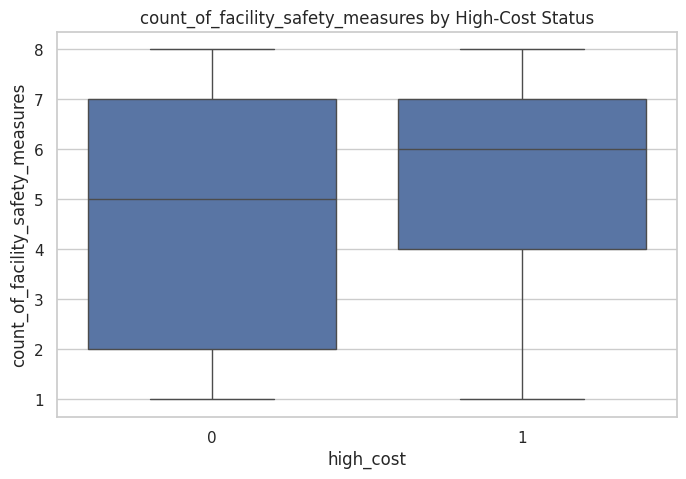

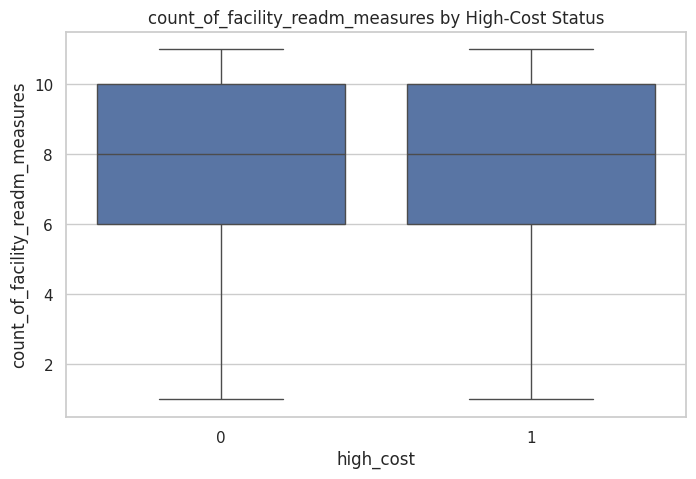

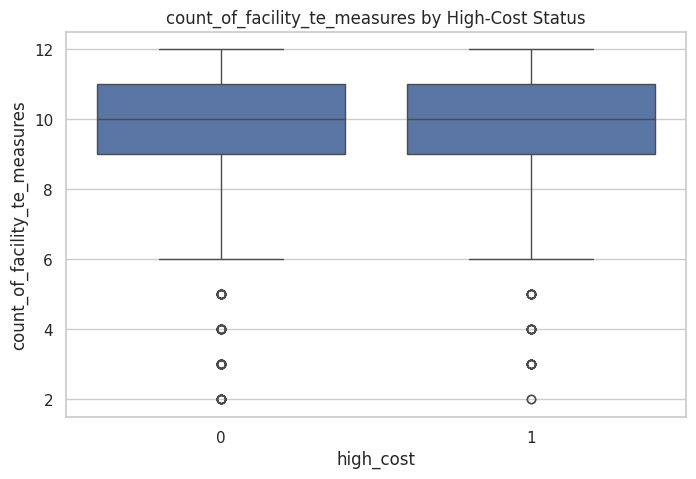

<Figure size 1600x1000 with 0 Axes>

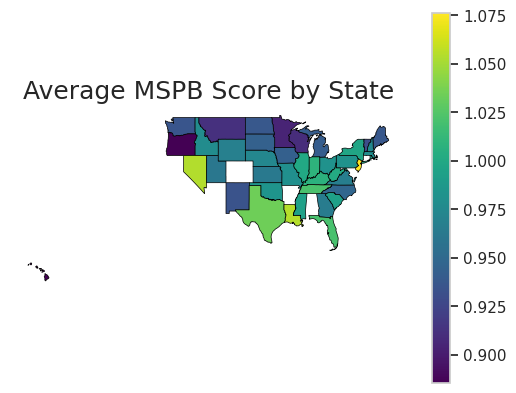

Logistic Regression
Accuracy: 0.5865051903114187
              precision    recall  f1-score   support

           0       0.63      0.53      0.58       305
           1       0.55      0.65      0.60       273

    accuracy                           0.59       578
   macro avg       0.59      0.59      0.59       578
weighted avg       0.59      0.59      0.59       578

[[162 143]
 [ 96 177]]
Decision Tree
Accuracy: 0.5570934256055363
              precision    recall  f1-score   support

           0       0.58      0.61      0.59       305
           1       0.53      0.50      0.52       273

    accuracy                           0.56       578
   macro avg       0.55      0.55      0.55       578
weighted avg       0.56      0.56      0.56       578

[[186 119]
 [137 136]]
Random Forest
Accuracy: 0.5709342560553633
              precision    recall  f1-score   support

           0       0.59      0.61      0.60       305
           1       0.55      0.53      0.54       273

 

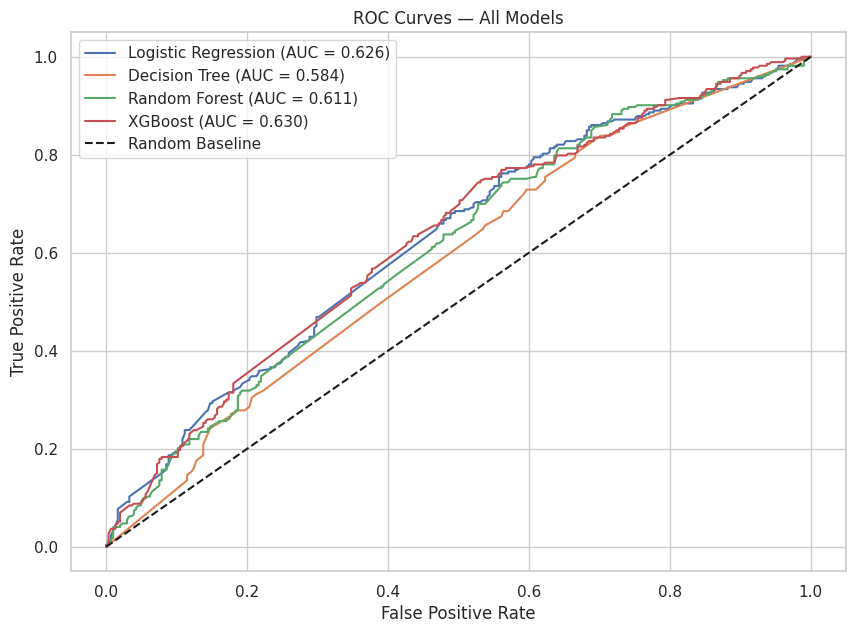

                 Model       AUC
0  Logistic Regression  0.625785
1        Decision Tree  0.584369
2        Random Forest  0.611085
3              XGBoost  0.629544


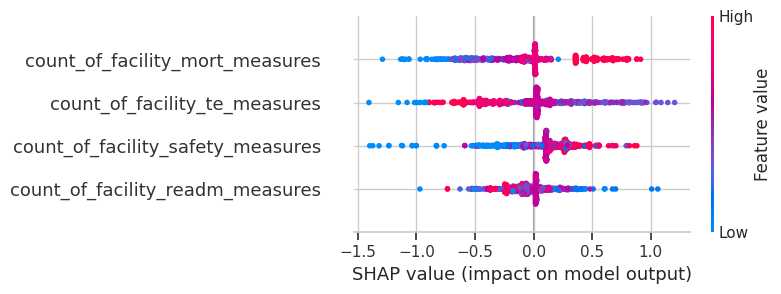

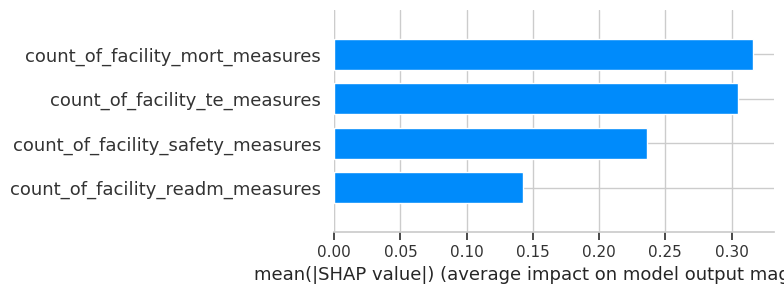

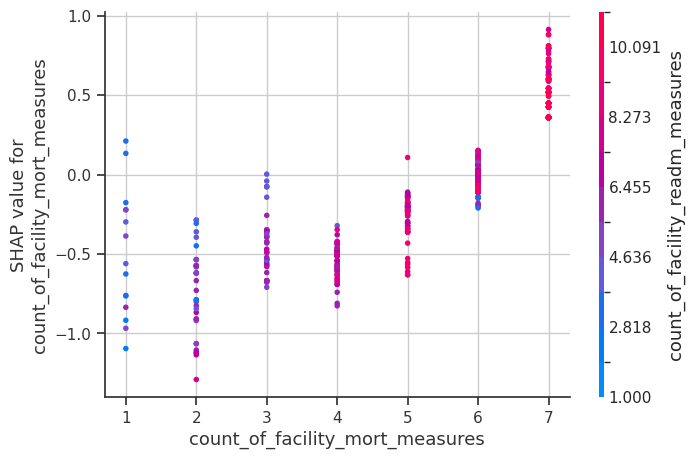

In [ ]:
# =============================================================================
# Predicting High-Cost Hospitals Using AI and MSPB Data
# =============================================================================
# Medicare Spending Per Beneficiary (MSPB) is a key metric used by CMS to
# evaluate how efficiently hospitals deliver care. MSPB captures all Medicare
# Part A and Part B spending during a patient's full episode of care, including
# the three days before admission, the inpatient stay, and the thirty days
# after discharge.
#
# High MSPB values indicate higher than expected spending after adjusting for
# patient risk and geographic payment differences.
#
# Project Goals:
# 1. Predict which hospitals are likely to have above-median MSPB spending.
# 2. Identify the hospital characteristics most associated with high spending.
# 3. Build interpretable AI models that support transparent decision making.
#
# Note: Causal inference exploration is planned for a future version.
# =============================================================================


# =============================================================================
# 1. DEPENDENCIES
# =============================================================================

!pip install shap xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from xgboost import XGBClassifier
import shap

sns.set(style="whitegrid")


# =============================================================================
# 2. LOAD DATA
# =============================================================================

from google.colab import files

# Load MSPB dataset
# CMS labels the downloadable file as "Medicare Hospital Spending Per Patient"
uploaded = files.upload()
mspb = pd.read_csv(list(uploaded.keys())[0])

# Load Hospital General Information dataset
uploaded = files.upload()
hosp = pd.read_csv(list(uploaded.keys())[0])


# =============================================================================
# 3. CLEAN AND MERGE
# =============================================================================

def clean_columns(df):
    df.columns = (
        df.columns
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
        .str.replace("/", "_")
    )
    return df

mspb = clean_columns(mspb)
hosp = clean_columns(hosp)

# Convert score to numeric and drop nulls
mspb['score'] = pd.to_numeric(mspb['score'], errors='coerce')
mspb = mspb.dropna(subset=['score'])

# Create binary target: 1 if above median MSPB, 0 otherwise
median_mspb = mspb['score'].median()
mspb['high_cost'] = (mspb['score'] > median_mspb).astype(int)

# Merge on facility ID
mspb['facility_id'] = mspb['facility_id'].astype(str)
hosp['facility_id'] = hosp['facility_id'].astype(str)

df = mspb.merge(hosp, on='facility_id', how='left')

# Clean up duplicate columns from merge
df = df.drop(columns=[
    'facility_name_x', 'address_x', 'city_town_x', 'state_x',
    'zip_code_x', 'county_parish_x', 'telephone_number_x'
], errors='ignore')

df = df.rename(columns={
    'facility_name_y': 'facility_name',
    'address_y': 'address',
    'city_town_y': 'city_town',
    'state_y': 'state',
    'zip_code_y': 'zip_code',
    'county_parish_y': 'county_parish',
    'telephone_number_y': 'telephone_number'
})

df = df.drop(columns=[
    'measure_id', 'measure_name', 'footnote',
    'start_date', 'end_date'
], errors='ignore')

# Convert quality measure columns to numeric
cols_to_numeric = [
    'mort_group_measure_count', 'count_of_facility_mort_measures',
    'count_of_mort_measures_better', 'count_of_mort_measures_no_different',
    'count_of_mort_measures_worse', 'safety_group_measure_count',
    'count_of_facility_safety_measures', 'count_of_safety_measures_better',
    'count_of_safety_measures_no_different', 'count_of_safety_measures_worse',
    'readm_group_measure_count', 'count_of_facility_readm_measures',
    'count_of_readm_measures_better', 'count_of_readm_measures_no_different',
    'count_of_readm_measures_worse', 'pt_exp_group_measure_count',
    'count_of_facility_pt_exp_measures', 'te_group_measure_count',
    'count_of_facility_te_measures'
]

for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')


# =============================================================================
# 4. EXPLORATORY DATA ANALYSIS
# =============================================================================

# --- MSPB Score Distribution ---
plt.figure(figsize=(8, 5))
sns.histplot(mspb['score'], kde=True, bins=30)
plt.title("Distribution of MSPB Scores")
plt.xlabel("MSPB Score")
plt.ylabel("Count")
plt.show()

# --- High-Cost Label Distribution ---
df['high_cost'].value_counts().plot(kind='bar', color='purple')
plt.title("High-Cost Label Distribution")
plt.xlabel("High Cost (1 = Yes)")
plt.ylabel("Count")
plt.show()

# --- MSPB Score by State ---
plt.figure(figsize=(14, 6))
sns.boxplot(data=mspb, x='state', y='score')
plt.title("MSPB Score Distribution by State")
plt.xticks(rotation=90)
plt.show()

# --- Average MSPB Score by State ---
state_mspb = df.groupby('state')['score'].mean().sort_values()

plt.figure(figsize=(14, 8))
sns.barplot(x=state_mspb.index, y=state_mspb.values, palette='viridis')
plt.xticks(rotation=90)
plt.title("Average MSPB Score by State")
plt.ylabel("Average MSPB Score")
plt.xlabel("State")
plt.show()

# --- Proportion of High-Cost Hospitals by State ---
high_cost_rate = df.groupby('state')['high_cost'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(x=high_cost_rate.index, y=high_cost_rate.values, palette='rocket')
plt.xticks(rotation=90)
plt.title("Proportion of High-Cost Hospitals by State")
plt.ylabel("High-Cost Rate")
plt.xlabel("State")
plt.show()

# --- MSPB Score by U.S. Census Region ---
region_map = {
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast',
    'RI': 'Northeast', 'VT': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast',
    'PA': 'Northeast',
    'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest', 'OH': 'Midwest',
    'WI': 'Midwest', 'IA': 'Midwest', 'KS': 'Midwest', 'MN': 'Midwest',
    'MO': 'Midwest', 'NE': 'Midwest', 'ND': 'Midwest', 'SD': 'Midwest',
    'DE': 'South', 'FL': 'South', 'GA': 'South', 'MD': 'South', 'NC': 'South',
    'SC': 'South', 'VA': 'South', 'DC': 'South', 'WV': 'South', 'AL': 'South',
    'KY': 'South', 'MS': 'South', 'TN': 'South', 'AR': 'South', 'LA': 'South',
    'OK': 'South', 'TX': 'South',
    'AZ': 'West', 'CO': 'West', 'ID': 'West', 'MT': 'West', 'NV': 'West',
    'NM': 'West', 'UT': 'West', 'WY': 'West', 'AK': 'West', 'CA': 'West',
    'HI': 'West', 'OR': 'West', 'WA': 'West'
}

df['region'] = df['state'].map(region_map)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='region', y='score', palette='Set2')
plt.title("MSPB Score by U.S. Census Region")
plt.show()

# --- Top 20 Highest MSPB Counties ---
county_mspb = df.groupby('county_parish')['score'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(y=county_mspb.head(20).index, x=county_mspb.head(20).values, palette='magma')
plt.title("Top 20 Highest MSPB Counties")
plt.xlabel("Average MSPB Score")
plt.ylabel("County")
plt.show()

# --- MSPB Score by Hospital Characteristics ---
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='hospital_ownership', y='score')
plt.xticks(rotation=45)
plt.title("MSPB Score by Hospital Ownership")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='hospital_type', y='score')
plt.xticks(rotation=45)
plt.title("MSPB Score by Hospital Type")
plt.show()

sns.boxplot(data=df, x='emergency_services', y='score')
plt.title("MSPB Score by Emergency Services Availability")
plt.show()

# --- Correlation Heatmap ---
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

# Top correlations with MSPB score
corr_with_score = corr['score'].sort_values(ascending=False)
top_corr = corr_with_score[1:11]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_corr.values, y=top_corr.index, color='teal')
plt.title("Top Correlations with MSPB Score")
plt.show()

# --- Quality Metrics vs MSPB Score ---
quality_cols = [
    'count_of_facility_mort_measures',
    'count_of_facility_safety_measures',
    'count_of_facility_readm_measures',
    'count_of_facility_te_measures'
]

for col in quality_cols:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=col, y='score', alpha=0.5)
    sns.regplot(data=df, x=col, y='score', scatter=False, color='red')
    plt.title(f"MSPB Score vs {col}")
    plt.show()

for col in quality_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='high_cost', y=col)
    plt.title(f"{col} by High-Cost Status")
    plt.show()

# --- Choropleth Map ---
!pip install geopandas shapely

import geopandas as gpd

state_name_map = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware',
    'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'ID': 'Idaho',
    'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa', 'KS': 'Kansas',
    'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota',
    'MS': 'Mississippi', 'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska',
    'NV': 'Nevada', 'NH': 'New Hampshire', 'NJ': 'New Jersey',
    'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina',
    'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma', 'OR': 'Oregon',
    'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah',
    'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington',
    'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming',
    'DC': 'District of Columbia'
}

df['state_full'] = df['state'].map(state_name_map)
state_mspb_full = df.groupby('state_full')['score'].mean().reset_index()

url = "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_20m.zip"
states_geo = gpd.read_file(url)
merged = states_geo.merge(state_mspb_full, left_on='NAME', right_on='state_full', how='left')

plt.figure(figsize=(16, 10))
merged.plot(column='score', cmap='viridis', legend=True, edgecolor='black', linewidth=0.5)
plt.title("Average MSPB Score by State", fontsize=18)
plt.axis('off')
plt.show()


# =============================================================================
# 5. FEATURE ENGINEERING AND PREPROCESSING
# =============================================================================

# Feature set excludes raw MSPB score to prevent data leakage.
# The target variable (high_cost) is defined as above/below median score,
# so including score as a feature would give the model direct access to
# the answer.

features = [
    'count_of_facility_mort_measures',
    'count_of_facility_safety_measures',
    'count_of_facility_readm_measures',
    'count_of_facility_te_measures'
]

target = 'high_cost'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)


# =============================================================================
# 6. MODELING
# =============================================================================

# --- Logistic Regression ---
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

# --- Decision Tree ---
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_imputed, y_train)
y_pred_dt = dt.predict(X_test_imputed)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=300, max_depth=None, random_state=42)
rf.fit(X_train_imputed, y_train)
y_pred_rf = rf.predict(X_test_imputed)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

# --- XGBoost ---
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train_imputed, y_train)
y_pred_xgb = xgb.predict(X_test_imputed)

print("XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

# --- Model Comparison ---
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
})
print(results)


# =============================================================================
# 7. EVALUATION — ROC / AUC
# =============================================================================

y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
y_prob_dt = dt.predict_proba(X_test_imputed)[:, 1]
y_prob_rf = rf.predict_proba(X_test_imputed)[:, 1]
y_prob_xgb = xgb.predict_proba(X_test_imputed)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

auc_lr = auc(fpr_lr, tpr_lr)
auc_dt = auc(fpr_dt, tpr_dt)
auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(10, 7))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend()
plt.show()

auc_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'AUC': [auc_lr, auc_dt, auc_rf, auc_xgb]
})
print(auc_results)


# =============================================================================
# 8. INTERPRETABILITY — SHAP
# =============================================================================

shap.initjs()

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_imputed)

# Summary plot — dot
shap.summary_plot(shap_values, X_test_imputed, feature_names=features, plot_type="dot")

# Summary plot — bar
shap.summary_plot(shap_values, X_test_imputed, feature_names=features, plot_type="bar")

# Dependence plot for top feature
shap.dependence_plot(0, shap_values, X_test_imputed, feature_names=features)